🔻 CELL 1: Import Library

In [1]:
# =======================================================
# 1. IMPORT LIBRARY
# =======================================================
import os
import cv2
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.utils import class_weight
from sklearn.model_selection import StratifiedShuffleSplit
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from IPython.display import display

# Bersihkan Memori di awal
tf.keras.backend.clear_session()
gc.collect()
print("✅ Library berhasil dimuat dan memori sistem bersih.")


✅ Library berhasil dimuat dan memori sistem bersih.


🔻 CELL 2: Control Panel

In [2]:
# =======================================================
# 2. 🎛️ CONTROL PANEL & PARAMETER UTAMA
# =======================================================
NOMOR_SKEMA = 5          # <--- PILIH SKEMA (1 sampai 6)
SKEMA_SPLIT = '80_20'    # <--- GANTI RASIO DI SINI ('90_10', '80_20', atau '70_30')
JUMLAH_ITERASI = 5       # <--- TETAP 5 ITERASI
BATCH_SIZE = 32

# Logika Otomatis Skenario
if NOMOR_SKEMA == 1: MODEL_TYPE, USE_CLAHE, DESC = 'MobileNetV2', False, "Skema 1: MobileNetV2 (Raw)"
elif NOMOR_SKEMA == 2: MODEL_TYPE, USE_CLAHE, DESC = 'Xception', False, "Skema 2: Xception (Raw)"
elif NOMOR_SKEMA == 3: MODEL_TYPE, USE_CLAHE, DESC = 'Hybrid', False, "Skema 3: SkinNetX (Raw)"
elif NOMOR_SKEMA == 4: MODEL_TYPE, USE_CLAHE, DESC = 'MobileNetV2', True, "Skema 4: MobileNetV2 + CLAHE"
elif NOMOR_SKEMA == 5: MODEL_TYPE, USE_CLAHE, DESC = 'Xception', True, "Skema 5: Xception + CLAHE"
elif NOMOR_SKEMA == 6: MODEL_TYPE, USE_CLAHE, DESC = 'Hybrid', True, "Skema 6: SkinNetX + CLAHE"

# Menentukan ukuran proporsi Test Size
if SKEMA_SPLIT == '90_10': test_size_ratio = 0.10
elif SKEMA_SPLIT == '80_20': test_size_ratio = 0.20
elif SKEMA_SPLIT == '70_30': test_size_ratio = 0.30

print(f"🚀 TARGET SKEMA: {DESC}")
print(f"📂 TARGET RASIO VIRTUAL: {SKEMA_SPLIT} (Train {100-int(test_size_ratio*100)}% : Val/Test {int(test_size_ratio*100)}%)")
print(f"🔄 JUMLAH ITERASI: {JUMLAH_ITERASI} Putaran")

🚀 TARGET SKEMA: Skema 5: Xception + CLAHE
📂 TARGET RASIO VIRTUAL: 80_20 (Train 80% : Val/Test 20%)
🔄 JUMLAH ITERASI: 5 Putaran


🔻 CELL 3: Persiapan Dataset (Dataframe)

In [3]:
# =======================================================
# 3. 📂 MEMBACA DATASET GABUNGAN
# =======================================================
target_gabungan = 'Dataset_Gabungan'
data_list = []

print("🔍 Membaca seluruh file gambar dari folder...")
for kelas in os.listdir(target_gabungan):
    folder_kelas = os.path.join(target_gabungan, kelas)
    if os.path.isdir(folder_kelas):
        for gambar in os.listdir(folder_kelas):
            data_list.append({'filename': os.path.join(folder_kelas, gambar), 'class': kelas})
            
df_dataset = pd.DataFrame(data_list)
print(f"✅ Total keseluruhan data: {len(df_dataset)} gambar siap digunakan.")

🔍 Membaca seluruh file gambar dari folder...
✅ Total keseluruhan data: 1429 gambar siap digunakan.


🔻 CELL 4: Preprocessing (CLAHE & Augmentasi)

In [4]:
# =======================================================
# 4. ⚙️ PENGATURAN AUGMENTASI & PREPROCESSING
# =======================================================
def clahe_prep(image):
    img_yuv = cv2.cvtColor(np.uint8(image), cv2.COLOR_RGB2YUV)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    img_yuv[:, :, 0] = clahe.apply(img_yuv[:, :, 0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    return img.astype(np.float32)

chosen_prep = clahe_prep if USE_CLAHE else None

train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=40, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True, vertical_flip=True, fill_mode='nearest',
    preprocessing_function=chosen_prep
)

val_test_datagen = ImageDataGenerator(rescale=1./255, preprocessing_function=chosen_prep)
print("✅ Fungsi Augmentasi dan CLAHE (jika aktif) sudah disiapkan.")

✅ Fungsi Augmentasi dan CLAHE (jika aktif) sudah disiapkan.


🔻 CELL 5: Master Looping (Training & Evaluasi Grafik)


🚀 MEMPROSES FOLD KE-1 DARI 5
Found 1143 validated image filenames belonging to 4 classes.
Found 286 validated image filenames belonging to 4 classes.

🏗️ Membangun Arsitektur: Xception...

⚙️ Memulai proses Training...


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.5824 - loss: 1.0853 - val_accuracy: 0.6523 - val_loss: 0.9669 - learning_rate: 1.0000e-04
Epoch 2/50
 1/35 ━━━━━━━━━━━━━━━━━━━━ 30s 891ms/step - accuracy: 0.7812 - loss: 0.6835

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.7812 - loss: 0.6835 - val_accuracy: 0.6484 - val_loss: 0.9545 - learning_rate: 1.0000e-04
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.7057 - loss: 0.7921 - val_accuracy: 0.7188 - val_loss: 0.7647 - learning_rate: 1.0000e-04
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 230ms/step - accuracy: 0.6562 - loss: 0.6966 - val_accuracy: 0.7227 - val_loss: 0.7589 - learning_rate: 1.0000e-04
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7462 - loss: 0.6735 - val_accuracy: 0.7500 - val_loss: 0.7087 - learning_rate: 1.0000e-04
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step - accuracy: 0.7500 - loss: 0.6691 - val_accuracy: 0.7578 - val_loss: 0.7111 - learning_rate: 1.0000e-04
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7903 - loss: 0.5932 - val_accuracy: 0.7773 - val_loss: 0.6345 - learning_rate: 1.0000e-04
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.7500 - loss: 0.

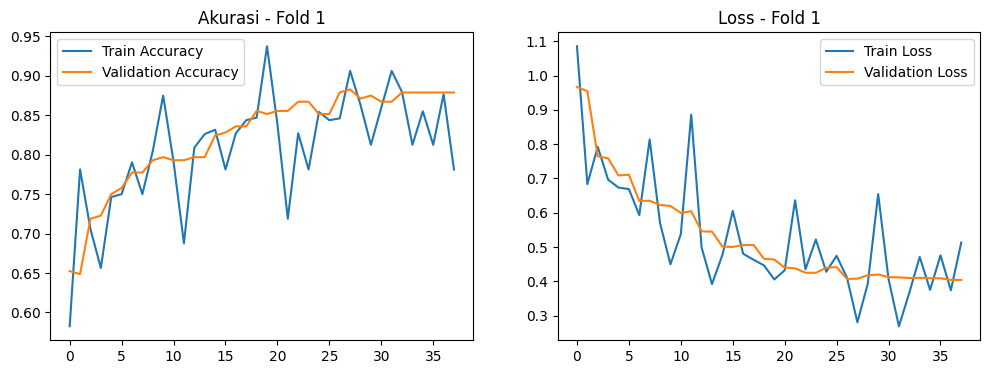


🏆 HASIL AKURASI FOLD 1: 88.81%
              precision    recall  f1-score   support

  Chickenpox       0.71      0.75      0.73        36
     Measles       0.84      0.80      0.82        40
   Monkeypox       0.95      0.89      0.92       105
      Normal       0.91      0.97      0.94       105

    accuracy                           0.89       286
   macro avg       0.85      0.85      0.85       286
weighted avg       0.89      0.89      0.89       286



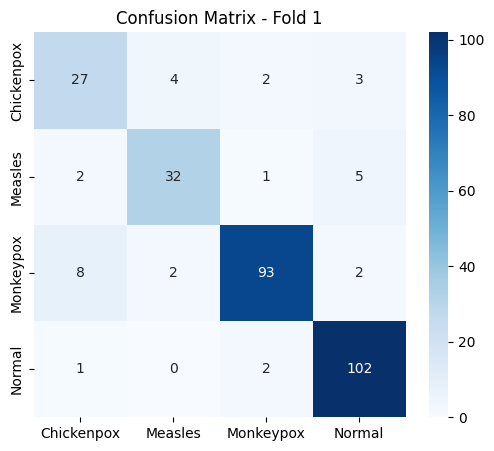


🚀 MEMPROSES FOLD KE-2 DARI 5
Found 1143 validated image filenames belonging to 4 classes.
Found 286 validated image filenames belonging to 4 classes.

🏗️ Membangun Arsitektur: Xception...

⚙️ Memulai proses Training...


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.5284 - loss: 1.1297 - val_accuracy: 0.7109 - val_loss: 0.9155 - learning_rate: 1.0000e-04
Epoch 2/50
 1/35 ━━━━━━━━━━━━━━━━━━━━ 32s 945ms/step - accuracy: 0.6562 - loss: 0.8812

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.6562 - loss: 0.8812 - val_accuracy: 0.7227 - val_loss: 0.9073 - learning_rate: 1.0000e-04
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6949 - loss: 0.8143 - val_accuracy: 0.7578 - val_loss: 0.7572 - learning_rate: 1.0000e-04
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step - accuracy: 0.5938 - loss: 0.8798 - val_accuracy: 0.7578 - val_loss: 0.7534 - learning_rate: 1.0000e-04
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7408 - loss: 0.7042 - val_accuracy: 0.7617 - val_loss: 0.6970 - learning_rate: 1.0000e-04
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step - accuracy: 0.7812 - loss: 0.7094 - val_accuracy: 0.7617 - val_loss: 0.6967 - learning_rate: 1.0000e-04
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7858 - loss: 0.6310 - val_accuracy: 0.7891 - val_loss: 0.6696 - learning_rate: 1.0000e-04
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - accuracy: 0.7812 - loss: 0.

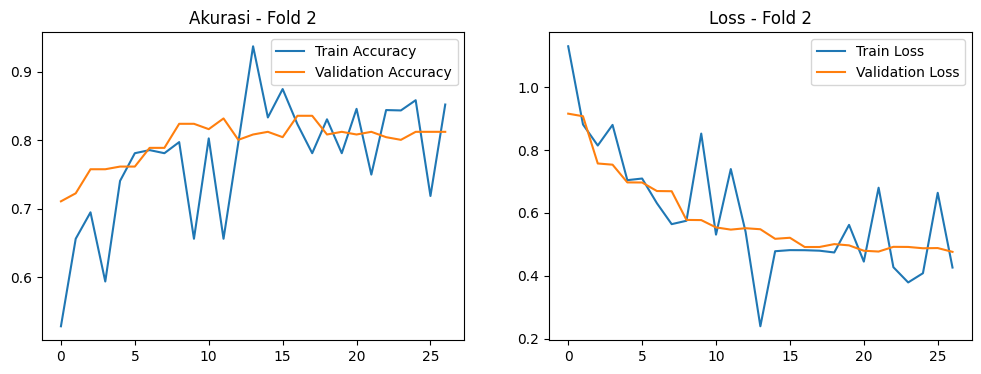


🏆 HASIL AKURASI FOLD 2: 85.31%
              precision    recall  f1-score   support

  Chickenpox       0.52      0.69      0.59        32
     Measles       0.84      0.74      0.78        42
   Monkeypox       0.97      0.85      0.91       110
      Normal       0.88      0.95      0.92       102

    accuracy                           0.85       286
   macro avg       0.80      0.81      0.80       286
weighted avg       0.87      0.85      0.86       286



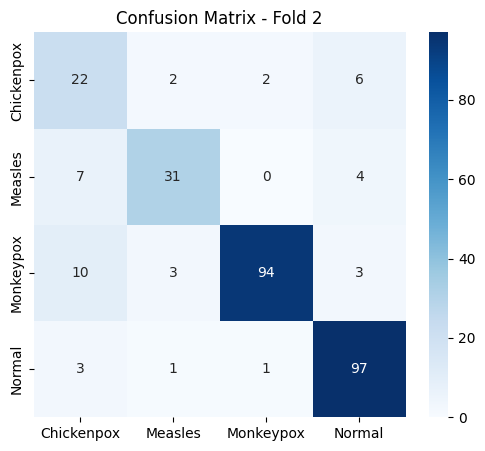


🚀 MEMPROSES FOLD KE-3 DARI 5
Found 1143 validated image filenames belonging to 4 classes.
Found 286 validated image filenames belonging to 4 classes.

🏗️ Membangun Arsitektur: Xception...

⚙️ Memulai proses Training...


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5455 - loss: 1.0921 - val_accuracy: 0.5938 - val_loss: 0.9969 - learning_rate: 1.0000e-04
Epoch 2/50
 1/35 ━━━━━━━━━━━━━━━━━━━━ 32s 954ms/step - accuracy: 0.6250 - loss: 0.8976

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.6250 - loss: 0.8976 - val_accuracy: 0.5938 - val_loss: 0.9857 - learning_rate: 1.0000e-04
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6973 - loss: 0.7779 - val_accuracy: 0.6484 - val_loss: 0.8449 - learning_rate: 1.0000e-04
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step - accuracy: 0.8696 - loss: 0.4934 - val_accuracy: 0.6484 - val_loss: 0.8409 - learning_rate: 1.0000e-04
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7516 - loss: 0.6907 - val_accuracy: 0.7227 - val_loss: 0.7356 - learning_rate: 1.0000e-04
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - accuracy: 0.8750 - loss: 0.4578 - val_accuracy: 0.7148 - val_loss: 0.7333 - learning_rate: 1.0000e-04
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7993 - loss: 0.5851 - val_accuracy: 0.7461 - val_loss: 0.6781 - learning_rate: 1.0000e-04
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 245ms/step - accuracy: 0.9062 - loss: 0.

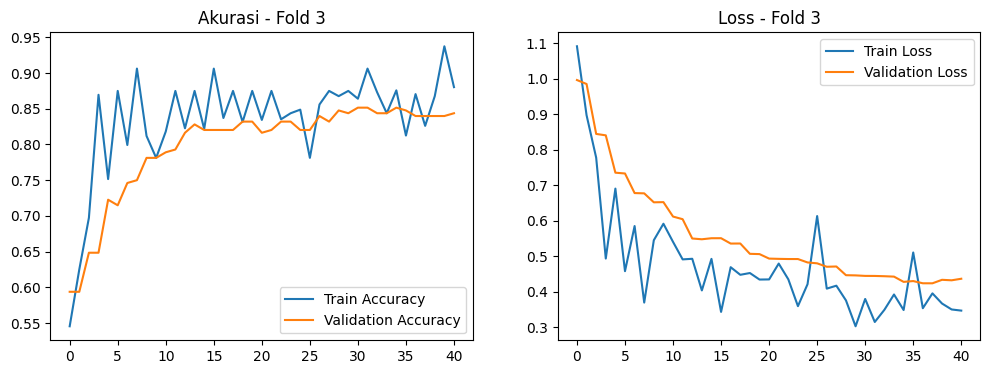


🏆 HASIL AKURASI FOLD 3: 86.01%
              precision    recall  f1-score   support

  Chickenpox       0.80      0.73      0.76        55
     Measles       0.91      0.76      0.83        38
   Monkeypox       0.85      0.89      0.87        99
      Normal       0.88      0.95      0.91        94

    accuracy                           0.86       286
   macro avg       0.86      0.83      0.84       286
weighted avg       0.86      0.86      0.86       286



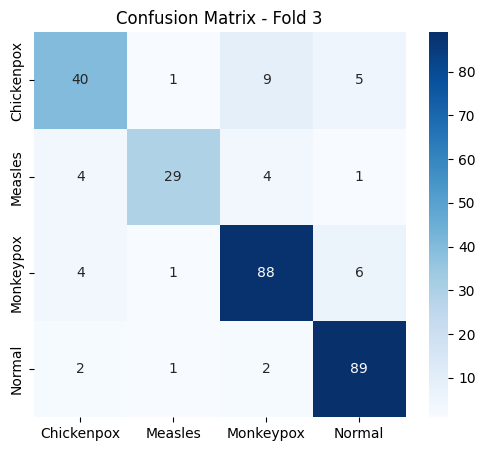


🚀 MEMPROSES FOLD KE-4 DARI 5
Found 1143 validated image filenames belonging to 4 classes.
Found 286 validated image filenames belonging to 4 classes.

🏗️ Membangun Arsitektur: Xception...

⚙️ Memulai proses Training...


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5365 - loss: 1.1581 - val_accuracy: 0.6484 - val_loss: 0.9341 - learning_rate: 1.0000e-04
Epoch 2/50
 1/35 ━━━━━━━━━━━━━━━━━━━━ 32s 953ms/step - accuracy: 0.8125 - loss: 0.8435

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 219ms/step - accuracy: 0.8125 - loss: 0.8435 - val_accuracy: 0.6484 - val_loss: 0.9268 - learning_rate: 1.0000e-04
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6877 - loss: 0.8300 - val_accuracy: 0.6953 - val_loss: 0.7873 - learning_rate: 1.0000e-04
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 218ms/step - accuracy: 0.8125 - loss: 0.6913 - val_accuracy: 0.6953 - val_loss: 0.7812 - learning_rate: 1.0000e-04
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7462 - loss: 0.6798 - val_accuracy: 0.7500 - val_loss: 0.7038 - learning_rate: 1.0000e-04
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 222ms/step - accuracy: 0.6562 - loss: 0.7473 - val_accuracy: 0.7461 - val_loss: 0.7087 - learning_rate: 1.0000e-04
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7840 - loss: 0.6124 - val_accuracy: 0.7539 - val_loss: 0.6458 - learning_rate: 1.0000e-04
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.8125 - loss: 0.

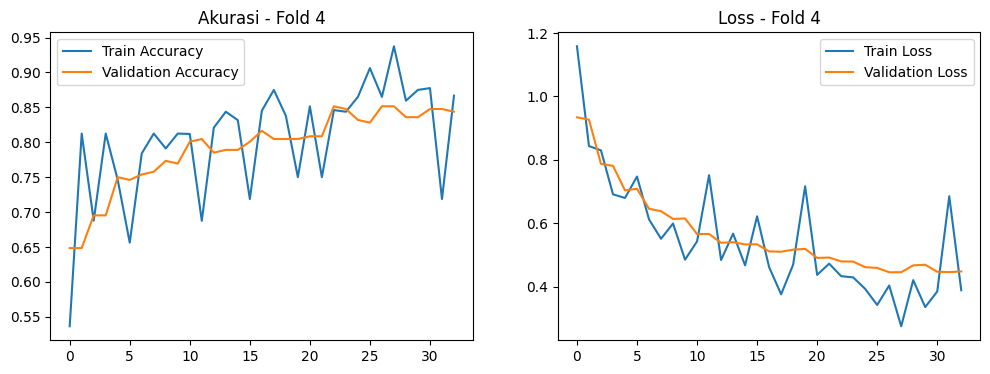


🏆 HASIL AKURASI FOLD 4: 86.36%
              precision    recall  f1-score   support

  Chickenpox       0.69      0.76      0.72        45
     Measles       0.69      0.81      0.75        27
   Monkeypox       0.95      0.84      0.89       122
      Normal       0.91      0.97      0.94        92

    accuracy                           0.86       286
   macro avg       0.81      0.84      0.82       286
weighted avg       0.87      0.86      0.87       286



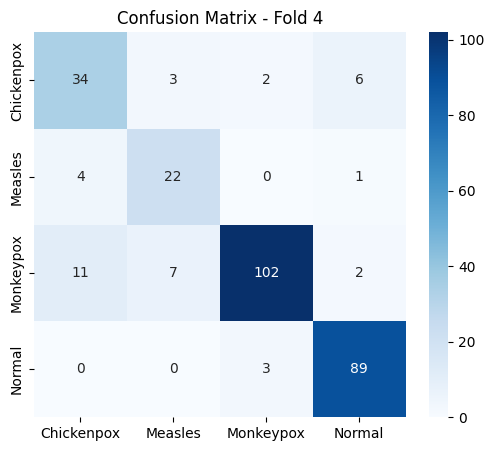


🚀 MEMPROSES FOLD KE-5 DARI 5
Found 1144 validated image filenames belonging to 4 classes.
Found 285 validated image filenames belonging to 4 classes.

🏗️ Membangun Arsitektur: Xception...

⚙️ Memulai proses Training...


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5674 - loss: 1.1078 - val_accuracy: 0.7305 - val_loss: 0.8369 - learning_rate: 1.0000e-04
Epoch 2/50
 1/35 ━━━━━━━━━━━━━━━━━━━━ 32s 955ms/step - accuracy: 0.5938 - loss: 0.9483

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 222ms/step - accuracy: 0.5938 - loss: 0.9483 - val_accuracy: 0.7266 - val_loss: 0.8319 - learning_rate: 1.0000e-04
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6942 - loss: 0.8192 - val_accuracy: 0.7422 - val_loss: 0.6921 - learning_rate: 1.0000e-04
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 243ms/step - accuracy: 0.8438 - loss: 0.6902 - val_accuracy: 0.7500 - val_loss: 0.6895 - learning_rate: 1.0000e-04
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7302 - loss: 0.7238 - val_accuracy: 0.8164 - val_loss: 0.5962 - learning_rate: 1.0000e-04
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 221ms/step - accuracy: 0.8125 - loss: 0.5826 - val_accuracy: 0.8047 - val_loss: 0.5954 - learning_rate: 1.0000e-04
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7662 - loss: 0.6711 - val_accuracy: 0.8047 - val_loss: 0.5672 - learning_rate: 1.0000e-04
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - accuracy: 0.7812 - loss: 0.

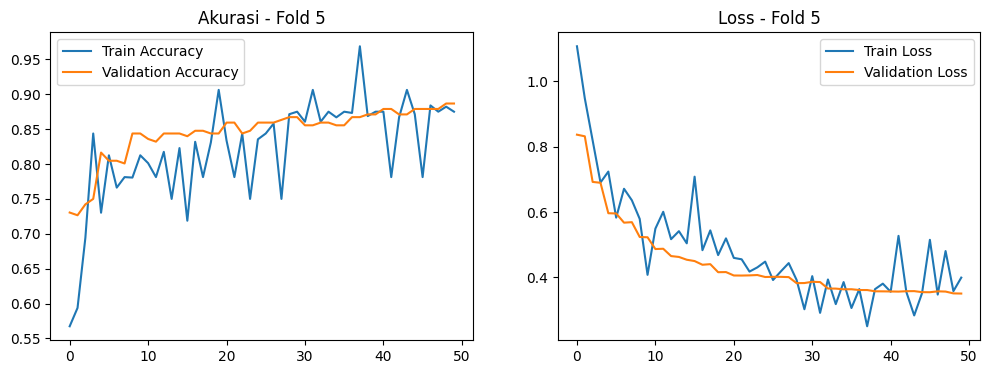


🏆 HASIL AKURASI FOLD 5: 89.47%
              precision    recall  f1-score   support

  Chickenpox       0.81      0.67      0.73        39
     Measles       0.78      0.88      0.82        24
   Monkeypox       0.90      0.93      0.91       107
      Normal       0.94      0.95      0.94       115

    accuracy                           0.89       285
   macro avg       0.86      0.85      0.85       285
weighted avg       0.89      0.89      0.89       285



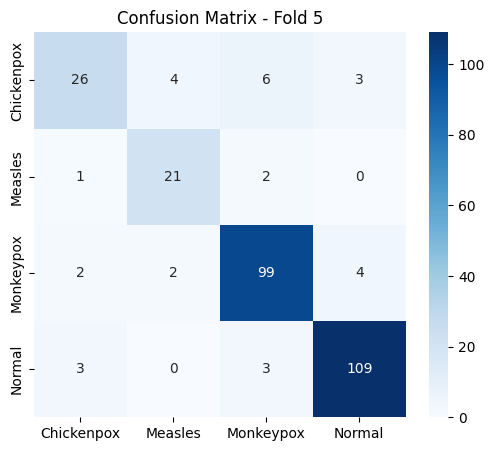


📊 TABEL REKAPITULASI 5-FOLD CROSS VALIDATION:


,K-Fold,Akurasi (%),Presisi (%),Recall (%),F1-Score (%)
0,1,88.81,85.31,85.18,85.16
1,2,85.31,80.31,80.78,80.07
2,3,86.01,86.05,83.15,84.36
3,4,86.36,81.07,84.35,82.42
4,5,89.47,85.75,85.37,85.30
5,Rata-rata,87.20,83.70,83.76,83.46
6,Standar Deviasi,1.83,2.77,1.88,2.22


In [5]:
# =======================================================
# 5. 🚀 MASTER ITERASI (K-FOLD, TRAINING, GRAFIK, EVALUASI)
# =======================================================
from sklearn.model_selection import KFold

# 1. Inisialisasi K-Fold sesuai permintaan dosen
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_no = 1
fold_results = [] 

# Menggunakan kf.split untuk membagi dataset menjadi 5 bagian
for train_index, val_index in kf.split(df_dataset):
    print(f"\n{'='*60}")
    print(f"🚀 MEMPROSES FOLD KE-{fold_no} DARI 5")
    print(f"{'='*60}")
    
    train_data = df_dataset.iloc[train_index]
    val_data = df_dataset.iloc[val_index]
    
    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_data, x_col='filename', y_col='class',
        target_size=(224, 224), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
    )
    val_gen = val_test_datagen.flow_from_dataframe(
        dataframe=val_data, x_col='filename', y_col='class',
        target_size=(224, 224), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )
        
    # Build Model
    print(f"\n🏗️ Membangun Arsitektur: {MODEL_TYPE}...")
    tf.keras.backend.clear_session()
    gc.collect()

    inp = Input(shape=(224, 224, 3))
    num_cls = len(train_gen.class_indices)

    # Logika arsitektur model (MobileNetV2, Xception, Hybrid) tetap sama
    if MODEL_TYPE == 'MobileNetV2':
        base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)
        base.trainable = False
        x = GlobalAveragePooling2D()(base.output)
        x = Dense(256, activation='relu')(x)
        x = Dropout(0.5)(x)
        out = Dense(num_cls, activation='softmax')(x)
        model = Model(inp, out)

    elif MODEL_TYPE == 'Xception':
        base = Xception(weights='imagenet', include_top=False, input_tensor=inp)
        base.trainable = False
        x = GlobalAveragePooling2D()(base.output)
        x = Dense(256, activation='relu')(x)
        x = Dropout(0.5)(x)
        out = Dense(num_cls, activation='softmax')(x)
        model = Model(inp, out)

    elif MODEL_TYPE == 'Hybrid':
        mob = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inp)
        for l in mob.layers: l._name = l.name + '_mob'
        x1 = GlobalAveragePooling2D()(mob.output)
        
        xcep = Xception(weights='imagenet', include_top=False, input_tensor=inp)
        for l in xcep.layers: l._name = l.name + '_xcep'
        x2 = GlobalAveragePooling2D()(xcep.output)
        
        merged = Concatenate()([x1, x2])
        x = Dense(256, activation='relu')(merged)
        x = Dropout(0.5)(x)
        out = Dense(num_cls, activation='softmax')(x)
        model = Model(inp, out)
        
        mob.trainable = False
        xcep.trainable = False

    model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Callback & Training
    ckpt = ModelCheckpoint(f"Model_Fold{fold_no}.keras", monitor='val_accuracy', save_best_only=True, mode='max')
    estop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
    redlr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6)
    
    print(f"\n⚙️ Memulai proses Training...")
    history = model.fit(
        train_gen, steps_per_epoch=train_gen.samples // BATCH_SIZE, epochs=50,
        validation_data=val_gen, validation_steps=val_gen.samples // BATCH_SIZE,
        callbacks=[ckpt, estop, redlr], verbose=1
    )
    
    # Visualisasi Grafik Akurasi & Loss per Fold
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Akurasi - Fold {fold_no}'); plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss - Fold {fold_no}'); plt.legend()
    plt.show()
    
    # Evaluasi & Classification Report
    val_gen.reset()
    preds = np.argmax(model.predict(val_gen, verbose=0), axis=1)
    y_true = val_gen.classes
    nama_kelas = list(train_gen.class_indices.keys())
    
    loss_val, acc_val = model.evaluate(val_gen, verbose=0)
    print(f"\n🏆 HASIL AKURASI FOLD {fold_no}: {acc_val*100:.2f}%")
    print(classification_report(y_true, preds, target_names=nama_kelas))

    # Confusion Matrix
    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nama_kelas, yticklabels=nama_kelas)
    plt.title(f'Confusion Matrix - Fold {fold_no}'); plt.show()
    
    # Mencatat Metrik untuk Rekapitulasi Akhir
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average='macro')
    fold_results.append({
        'K-Fold': fold_no,
        'Akurasi (%)': acc_val * 100,
        'Presisi (%)': prec * 100,
        'Recall (%)': rec * 100,
        'F1-Score (%)': f1 * 100
    })
    
    fold_no += 1

# =======================================================
# 6. 📊 TABEL REKAPITULASI & STANDAR DEVIASI
# =======================================================
df_rekap = pd.DataFrame(fold_results)

# Menghitung Rata-rata dan Standar Deviasi
rata_rata = df_rekap.mean(numeric_only=True)
standar_deviasi = df_rekap.std(numeric_only=True)

# Menambahkan baris Rata-rata dan Standar Deviasi ke DataFrame
df_rekap.loc[len(df_rekap)] = ['Rata-rata'] + rata_rata[1:].tolist()
df_rekap.loc[len(df_rekap)] = ['Standar Deviasi'] + standar_deviasi[1:].tolist()

df_rekap = df_rekap.round(2)
print(f"\n📊 TABEL REKAPITULASI 5-FOLD CROSS VALIDATION:")
display(df_rekap)

🔻 CELL 6: Cetak Tabel Rekapitulasi Akhir

In [ ]:
# =======================================================
# 6. 📊 TABEL REKAPITULASI AKHIR (COPY KE WORD)
# =======================================================
import pandas as pd

print("\n" + "="*60)
print(f"🎉 SEMUA PROSES EVALUASI 5-FOLD SELESAI!")
print("="*60)

# 1. Mengubah list fold_results menjadi DataFrame
df_rekap = pd.DataFrame(fold_results)

# 2. Menghitung Rata-rata untuk setiap kolom numerik
rata_rata = df_rekap.mean(numeric_only=True)
rata_rata['K-Fold'] = 'Rata-rata'

# 3. Menghitung Standar Deviasi (Sesuai permintaan dosen)
# Metrik ini penting untuk melihat kestabilan model di setiap fold
std_dev = df_rekap.std(numeric_only=True)
std_dev['K-Fold'] = 'Standar Deviasi'

# 4. Menggabungkan baris Rata-rata dan Standar Deviasi ke tabel utama
df_final = pd.concat([df_rekap, pd.DataFrame([rata_rata]), pd.DataFrame([std_dev])], ignore_index=True)

# 5. Membulatkan angka menjadi 2 desimal agar rapi saat dicopy ke Word
df_final = df_final.round(2)

# Mengatur urutan kolom agar K-Fold berada di depan
cols = ['K-Fold', 'Akurasi (%)', 'Presisi (%)', 'Recall (%)', 'F1-Score (%)']
df_final = df_final[cols]

print(f"\n📊 TABEL REKAPITULASI HASIL 5-FOLD CROSS VALIDATION ({MODEL_TYPE}):")
display(df_final)

# Pesan penutup untuk validasi cepat
print(f"\n✅ Ringkasan Akhir:")
print(f"   Model                : {DESC}")
print(f"   Rata-rata Akurasi    : {df_final.iloc[-2]['Akurasi (%)']}%")
print(f"   Standar Deviasi (±)  : {df_final.iloc[-1]['Akurasi (%)']}")


🎉 SEMUA PROSES EVALUASI 5-FOLD SELESAI!

📊 TABEL REKAPITULASI HASIL 5-FOLD CROSS VALIDATION (Xception):


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_33800\1266238475.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Rata-rata' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  rata_rata['K-Fold'] = 'Rata-rata'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_33800\1266238475.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Standar Deviasi' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  std_dev['K-Fold'] = 'Standar Deviasi'


,K-Fold,Akurasi (%),Presisi (%),Recall (%),F1-Score (%)
0,1,88.81,85.31,85.18,85.16
1,2,85.31,80.31,80.78,80.07
2,3,86.01,86.05,83.15,84.36
3,4,86.36,81.07,84.35,82.42
4,5,89.47,85.75,85.37,85.30
5,Rata-rata,87.20,83.70,83.76,83.46
6,Standar Deviasi,1.83,2.77,1.88,2.22



✅ Ringkasan Akhir:
   Model                : Skema 5: Xception + CLAHE
   Rata-rata Akurasi    : 87.2%
   Standar Deviasi (±)  : 1.83
